# Lucas Phase 2: Short-Run Policy Effectiveness (LP-IV)

## Objective
Estimate short-run monetary policy effectiveness in annual cross-country data using **local projections with IV**.

## Design
- Method: panel local projections + shock IV.
- Horizons: `h = 0,1,2,3`.
- Outcomes: `inflation`, `gdp_growth`.
- Primary instrument: `instrument_m2_external_level`.
- Sensitivity instrument: `instrument_m2_l1`.

This notebook is the pivot implementation after Phase 1 audit recommended `GO_PIVOT_SHORT_RUN`.


## Interpretation Rules

- Primary read: sign, magnitude, and confidence interval of `m2_growth` effect by horizon.
- First-stage quality: use approximate `F=t^2` from first-stage TWFE OLS in each horizon sample.
- Caution: annual data and FE IV can still carry identification risk; treat this as defensible applied evidence, not final structural truth.


In [1]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from linearmodels.iv import IV2SLS
from IPython.display import display

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

ROOT = Path('/Users/stevenchung/Desktop/P12B_File/New project_')
BASE_PATH = ROOT / 'macro_growth_merged.csv'
CTRL_PATH = ROOT / 'data/phase1_controls.csv'
IV_PATH = ROOT / 'data/phase1_instruments.csv'

OUT = ROOT / 'outputs/phase2_short_run'
OUT_T = OUT / 'tables'
OUT_F = OUT / 'figures'
OUT_T.mkdir(parents=True, exist_ok=True)
OUT_F.mkdir(parents=True, exist_ok=True)

LOG = []

def log(msg):
    print(msg)
    LOG.append(str(msg))

assert BASE_PATH.exists(), f'Missing {BASE_PATH}'
assert CTRL_PATH.exists(), f'Missing {CTRL_PATH}'
assert IV_PATH.exists(), f'Missing {IV_PATH}'


In [2]:
base = pd.read_csv(BASE_PATH)
ctrl = pd.read_csv(CTRL_PATH)
iv = pd.read_csv(IV_PATH)

df = base.merge(ctrl, on=['Country Name', 'year'], how='left')
df = df.merge(iv, on=['Country Name', 'year'], how='left')

df = df.sort_values(['Country Name', 'year']).copy()

# Restricted controls to avoid mechanical overlap with GDP-growth outcome.
controls = ['trade_open', 'pop_growth', 'investment_share']

# Horizon leads for local projections
for y in ['inflation', 'gdp_growth']:
    for h in [0,1,2,3]:
        df[f'{y}_h{h}'] = df.groupby('Country Name')[y].shift(-h)

summary = pd.DataFrame([
    {'metric': 'rows', 'value': len(df)},
    {'metric': 'countries', 'value': df['Country Name'].nunique()},
    {'metric': 'year_min', 'value': int(df['year'].min())},
    {'metric': 'year_max', 'value': int(df['year'].max())},
])

display(summary)
summary.to_csv(OUT_T / 'phase2_data_summary.csv', index=False)
log('Data prepared with local-projection horizons.')


,metric,value
0,rows,4292
1,countries,163
2,year_min,1991
3,year_max,2020


Data prepared with local-projection horizons.


In [3]:

def two_way_demean(df_in, col, entity_col='country', time_col='year'):
    x = df_in[col]
    ent_mean = df_in.groupby(entity_col)[col].transform('mean')
    time_mean = df_in.groupby(time_col)[col].transform('mean')
    grand_mean = x.mean()
    return x - ent_mean - time_mean + grand_mean


def run_lp_iv(df_in, outcome, horizon, instrument, controls):
    ycol = f'{outcome}_h{horizon}'
    cols = ['Country Name', 'year', ycol, 'm2_growth', instrument] + controls
    d = df_in[cols].dropna().copy().rename(columns={'Country Name': 'country'})

    # Two-way demean all variables to absorb country and year fixed effects fast.
    dm_cols = [ycol, 'm2_growth', instrument] + controls
    for v in dm_cols:
        d[f'{v}_dm'] = two_way_demean(d, v, entity_col='country', time_col='year')

    y_dm = f'{ycol}_dm'
    m_dm = 'm2_growth_dm'
    z_dm = f'{instrument}_dm'
    c_dm = [f'{x}_dm' for x in controls]

    # First stage on demeaned sample
    fs_formula = m_dm + ' ~ 0 + ' + z_dm
    if c_dm:
        fs_formula += ' + ' + ' + '.join(c_dm)
    fs = smf.ols(fs_formula, data=d).fit()
    fs_t = float(fs.tvalues[z_dm])
    fs_f = float(fs_t ** 2)

    # 2SLS on demeaned variables
    iv_formula = y_dm + ' ~ 0'
    if c_dm:
        iv_formula += ' + ' + ' + '.join(c_dm)
    iv_formula += f' + [{m_dm} ~ {z_dm}]'

    iv_res = IV2SLS.from_formula(iv_formula, data=d).fit(cov_type='robust')

    coef = float(iv_res.params[m_dm])
    se = float(iv_res.std_errors[m_dm])
    p = float(iv_res.pvalues[m_dm])

    return {
        'outcome': outcome,
        'horizon': horizon,
        'instrument': instrument,
        'coef_m2_growth': coef,
        'std_error': se,
        'p_value': p,
        'ci_low_95': coef - 1.96 * se,
        'ci_high_95': coef + 1.96 * se,
        'nobs': int(iv_res.nobs),
        'first_stage_t': fs_t,
        'first_stage_F_proxy': fs_f,
        'iv_r2': float(iv_res.rsquared),
    }


In [4]:
rows = []
instruments = ['instrument_m2_external_level', 'instrument_m2_l1']
outcomes = ['inflation', 'gdp_growth']
horizons = [0,1,2,3]

for inst in instruments:
    for y in outcomes:
        for h in horizons:
            try:
                r = run_lp_iv(df, outcome=y, horizon=h, instrument=inst, controls=controls)
                rows.append(r)
            except Exception as e:
                log(f'LP-IV failed: outcome={y}, h={h}, instrument={inst} -> {e}')

lp_tbl = pd.DataFrame(rows).sort_values(['instrument','outcome','horizon'])
display(lp_tbl)

lp_tbl.to_csv(OUT_T / 'lp_iv_all_results.csv', index=False)
log(f'LP-IV estimation done. Rows={len(lp_tbl)}')


,outcome,horizon,instrument,coef_m2_growth,std_error,p_value,ci_low_95,ci_high_95,nobs,first_stage_t,first_stage_F_proxy,iv_r2
4,gdp_growth,0,instrument_m2_external_level,-0.300991,0.238104,0.206189,-0.767675,0.165693,3535,-1.819596,3.310930,-2.169869
5,gdp_growth,1,instrument_m2_external_level,-0.128568,0.133038,0.333844,-0.389322,0.132186,3393,-1.821081,3.316336,-0.436505
6,gdp_growth,2,instrument_m2_external_level,-0.152261,0.151437,0.314685,-0.449078,0.144556,3252,-1.711715,2.929969,-0.665942
7,gdp_growth,3,instrument_m2_external_level,-0.293088,0.241382,0.224668,-0.766196,0.180021,3111,-1.639221,2.687047,-2.708248
0,inflation,0,instrument_m2_external_level,1.009852,0.570614,0.076766,-0.108551,2.128256,3535,-1.819596,3.310930,0.000819
1,inflation,1,instrument_m2_external_level,0.687464,0.407384,0.091506,-0.111009,1.485937,3393,-1.821081,3.316336,-0.069803
2,inflation,2,instrument_m2_external_level,0.639863,0.458219,0.162590,-0.258246,1.537972,3252,-1.711715,2.929969,-0.792141
3,inflation,3,instrument_m2_external_level,0.605666,0.462130,0.189994,-0.300108,1.511440,3111,-1.639221,2.687047,-1.593282
12,gdp_growth,0,instrument_m2_l1,-0.021050,0.021254,0.321994,-0.062708,0.020609,3409,16.002733,256.087478,0.014908
13,gdp_growth,1,instrument_m2_l1,-0.022512,0.015108,0.136214,-0.052123,0.007100,3267,14.984600,224.538238,-0.011726


LP-IV estimation done. Rows=16


In [5]:
primary = lp_tbl[lp_tbl['instrument'] == 'instrument_m2_external_level'].copy()
alt = lp_tbl[lp_tbl['instrument'] == 'instrument_m2_l1'].copy()

primary.to_csv(OUT_T / 'lp_iv_primary_results.csv', index=False)
alt.to_csv(OUT_T / 'lp_iv_alt_results.csv', index=False)

# PowerBI-friendly long table
powerbi = lp_tbl.copy()
powerbi['is_sig_5pct'] = powerbi['p_value'] < 0.05
powerbi['abs_coef'] = powerbi['coef_m2_growth'].abs()
powerbi.to_csv(OUT_T / 'powerbi_lp_iv_summary.csv', index=False)

display(primary)


,outcome,horizon,instrument,coef_m2_growth,std_error,p_value,ci_low_95,ci_high_95,nobs,first_stage_t,first_stage_F_proxy,iv_r2
4,gdp_growth,0,instrument_m2_external_level,-0.300991,0.238104,0.206189,-0.767675,0.165693,3535,-1.819596,3.310930,-2.169869
5,gdp_growth,1,instrument_m2_external_level,-0.128568,0.133038,0.333844,-0.389322,0.132186,3393,-1.821081,3.316336,-0.436505
6,gdp_growth,2,instrument_m2_external_level,-0.152261,0.151437,0.314685,-0.449078,0.144556,3252,-1.711715,2.929969,-0.665942
7,gdp_growth,3,instrument_m2_external_level,-0.293088,0.241382,0.224668,-0.766196,0.180021,3111,-1.639221,2.687047,-2.708248
0,inflation,0,instrument_m2_external_level,1.009852,0.570614,0.076766,-0.108551,2.128256,3535,-1.819596,3.310930,0.000819
1,inflation,1,instrument_m2_external_level,0.687464,0.407384,0.091506,-0.111009,1.485937,3393,-1.821081,3.316336,-0.069803
2,inflation,2,instrument_m2_external_level,0.639863,0.458219,0.162590,-0.258246,1.537972,3252,-1.711715,2.929969,-0.792141
3,inflation,3,instrument_m2_external_level,0.605666,0.462130,0.189994,-0.300108,1.511440,3111,-1.639221,2.687047,-1.593282


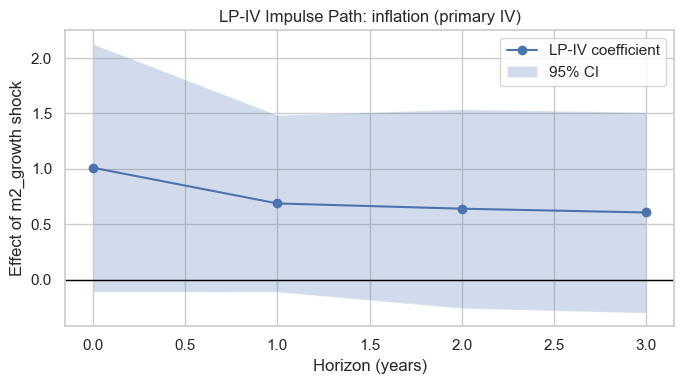

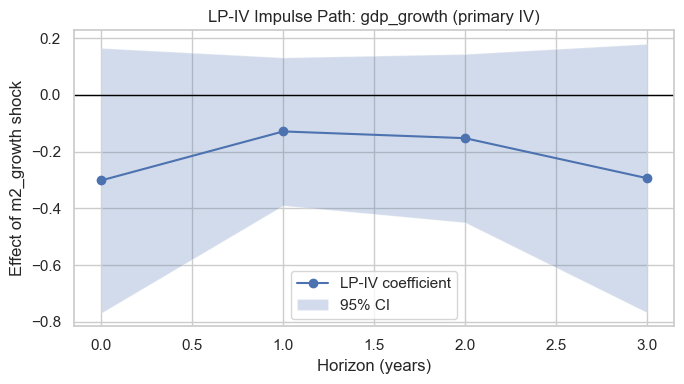

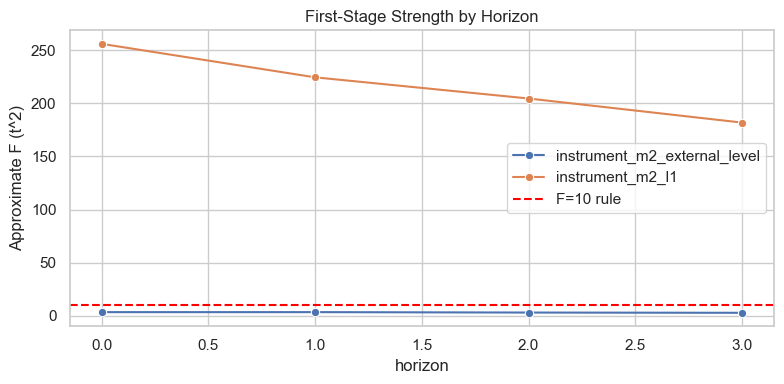

In [6]:
# IRF plots (primary instrument)
for y in ['inflation', 'gdp_growth']:
    d = primary[primary['outcome'] == y].sort_values('horizon').copy()
    fig, ax = plt.subplots(figsize=(7,4))
    ax.plot(d['horizon'], d['coef_m2_growth'], marker='o', label='LP-IV coefficient')
    ax.fill_between(d['horizon'], d['ci_low_95'], d['ci_high_95'], alpha=0.25, label='95% CI')
    ax.axhline(0, color='black', linewidth=1)
    ax.set_title(f'LP-IV Impulse Path: {y} (primary IV)')
    ax.set_xlabel('Horizon (years)')
    ax.set_ylabel('Effect of m2_growth shock')
    ax.legend()
    fig.tight_layout()
    fig.savefig(OUT_F / f'irf_primary_{y}.png', dpi=170)

# First-stage strength by horizon
fs_plot = lp_tbl.groupby(['instrument','horizon'], as_index=False)['first_stage_F_proxy'].mean()
fig2, ax2 = plt.subplots(figsize=(8,4))
sns.lineplot(data=fs_plot, x='horizon', y='first_stage_F_proxy', hue='instrument', marker='o', ax=ax2)
ax2.axhline(10, color='red', linestyle='--', label='F=10 rule')
ax2.set_title('First-Stage Strength by Horizon')
ax2.set_ylabel('Approximate F (t^2)')
ax2.legend()
fig2.tight_layout()
fig2.savefig(OUT_F / 'first_stage_by_horizon.png', dpi=170)

plt.show()


In [7]:
# Compact interpretation output
primary_inf = primary[primary['outcome']=='inflation'].sort_values('horizon')
primary_gdp = primary[primary['outcome']=='gdp_growth'].sort_values('horizon')

def sig_count(d):
    return int((d['p_value'] < 0.05).sum())

interp = pd.DataFrame([
    {
        'metric': 'inflation_sig_horizons_primary',
        'value': sig_count(primary_inf),
    },
    {
        'metric': 'gdp_sig_horizons_primary',
        'value': sig_count(primary_gdp),
    },
    {
        'metric': 'mean_first_stage_F_primary',
        'value': float(primary['first_stage_F_proxy'].mean()),
    },
    {
        'metric': 'mean_first_stage_F_alt_lag',
        'value': float(alt['first_stage_F_proxy'].mean()) if len(alt)>0 else np.nan,
    },
])

display(interp)
interp.to_csv(OUT_T / 'phase2_interpretation_metrics.csv', index=False)

rec = 'EVIDENCE_SHORT_RUN_EFFECT_PRESENT' if sig_count(primary_inf) >= 1 else 'EVIDENCE_WEAK_REVISIT_IDENTIFICATION'
log(f'Phase 2 interpretation recommendation: {rec}')

memo = OUT / 'phase2_short_run_interpretation.md'
lines = [
    '# Phase 2 Short-Run Interpretation',
    '',
    f'- Recommendation flag: `{rec}`',
    '',
    '## Reading guide',
    '- Focus first on primary IV (`instrument_m2_external_level`).',
    '- Compare horizon profile for inflation and GDP growth.',
    '- Use first-stage F by horizon as instrument strength sanity check.',
    '',
    '## Practical use in interview',
    '- This project now answers a short-run question with horizon-specific effects, rather than only long-run cross-country averages.',
    '- It explicitly reports identification caveats and first-stage diagnostics.',
]
memo.write_text('\n'.join(lines))


,metric,value
0,inflation_sig_horizons_primary,0.000000
1,gdp_sig_horizons_primary,0.000000
2,mean_first_stage_F_primary,3.061070
3,mean_first_stage_F_alt_lag,216.786199


Phase 2 interpretation recommendation: EVIDENCE_WEAK_REVISIT_IDENTIFICATION


537

In [8]:
# Manifest + log export
log_path = OUT / 'phase2_short_run_log.md'
log_path.write_text('\n'.join(['# Phase 2 Log', ''] + [f'- {x}' for x in LOG]))

manifest = pd.DataFrame({'artifact': [
    str(OUT_T / 'lp_iv_all_results.csv'),
    str(OUT_T / 'lp_iv_primary_results.csv'),
    str(OUT_T / 'lp_iv_alt_results.csv'),
    str(OUT_T / 'powerbi_lp_iv_summary.csv'),
    str(OUT_T / 'phase2_interpretation_metrics.csv'),
    str(OUT_F / 'irf_primary_inflation.png'),
    str(OUT_F / 'irf_primary_gdp_growth.png'),
    str(OUT_F / 'first_stage_by_horizon.png'),
    str(OUT / 'phase2_short_run_interpretation.md'),
    str(log_path),
]})
manifest.to_csv(OUT / 'phase2_manifest.csv', index=False)

display(manifest)
print('Manifest written to', OUT / 'phase2_manifest.csv')


,artifact
0,/Users/stevenchung/Desktop/P12B_File/New proje...
1,/Users/stevenchung/Desktop/P12B_File/New proje...
2,/Users/stevenchung/Desktop/P12B_File/New proje...
3,/Users/stevenchung/Desktop/P12B_File/New proje...
4,/Users/stevenchung/Desktop/P12B_File/New proje...
5,/Users/stevenchung/Desktop/P12B_File/New proje...
6,/Users/stevenchung/Desktop/P12B_File/New proje...
7,/Users/stevenchung/Desktop/P12B_File/New proje...
8,/Users/stevenchung/Desktop/P12B_File/New proje...
9,/Users/stevenchung/Desktop/P12B_File/New proje...


Manifest written to /Users/stevenchung/Desktop/P12B_File/New project_/outputs/phase2_short_run/phase2_manifest.csv


## Completion

- Notebook provides runnable short-run LP-IV evidence with horizon-specific effects.
- Outputs are ready for reporting and Power BI ingestion.
